# The four questions every Airbnb host is actually asking

Four cities. Four decisions, in the order a real host makes them: **where do I fit → how do I run it → does the money work → what could take it away.** Every chart below answers one of those, side by side across Antwerp, Amsterdam, LA, and Rio — so the differences are the point, not a footnote.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy import stats

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans', 'axes.edgecolor': '#333333',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.spines.left': False, 'axes.grid': False,
})

ORDER = ['Antwerp', 'Amsterdam', 'LA', 'Rio']
CITY_COLOR = {'Antwerp': '#2a9d8f', 'Amsterdam': '#264653', 'LA': '#e9c46a', 'Rio': '#e76f51'}
INK = '#1d1d1d'
MUTE = '#8a8a8a'

FILES = {
    'Antwerp':   ('/mnt/user-data/uploads/listings-Belgium.csv', 'EUR'),
    'Amsterdam': ('/mnt/user-data/uploads/listings-Netherlands.csv', 'EUR'),
    'Rio':       ('/mnt/user-data/uploads/listings-RIo_de_Janeiro.csv', 'BRL'),
    'LA':        ('/mnt/user-data/uploads/listings_California.csv', 'USD'),
}
frames = []
for city, (path, currency) in FILES.items():
    df = pd.read_csv(path)
    df['city'] = city; df['currency'] = currency
    df = df[df['price'] > 0].copy()
    df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
    frames.append(df)
data = pd.concat(frames, ignore_index=True)
data['price_index'] = data['price'] / data.groupby('city')['price'].transform('median')
data['professional'] = data['calculated_host_listings_count'] >= 3

def hbar_labels(ax, bars, values, fmt='{:.1f}', color=INK, offset=0.02, inside=False):
    xmax = max(abs(v) for v in values) or 1
    for bar, v in zip(bars, values):
        w = bar.get_width()
        x = w + (offset * xmax if w >= 0 else -offset * xmax)
        ha = 'left' if w >= 0 else 'right'
        if inside:
            x = w - np.sign(w) * offset * xmax
            ha = 'right' if w >= 0 else 'left'
            col = 'white'
        else:
            col = color
        ax.text(x, bar.get_y() + bar.get_height() / 2, fmt.format(v), va='center', ha=ha,
                 fontsize=10, fontweight='bold', color=col)

print('Loaded', len(data), 'listings across 4 cities.')

Loaded 90161 listings across 4 cities.


---
## Master Question 1 — Where do I actually fit in this market?

Before a price gets set, a host needs to know what kind of market they're stepping into: what's normal here, how many real competitors sit in their exact niche, and whether guessing the citywide average is safe or dangerous.

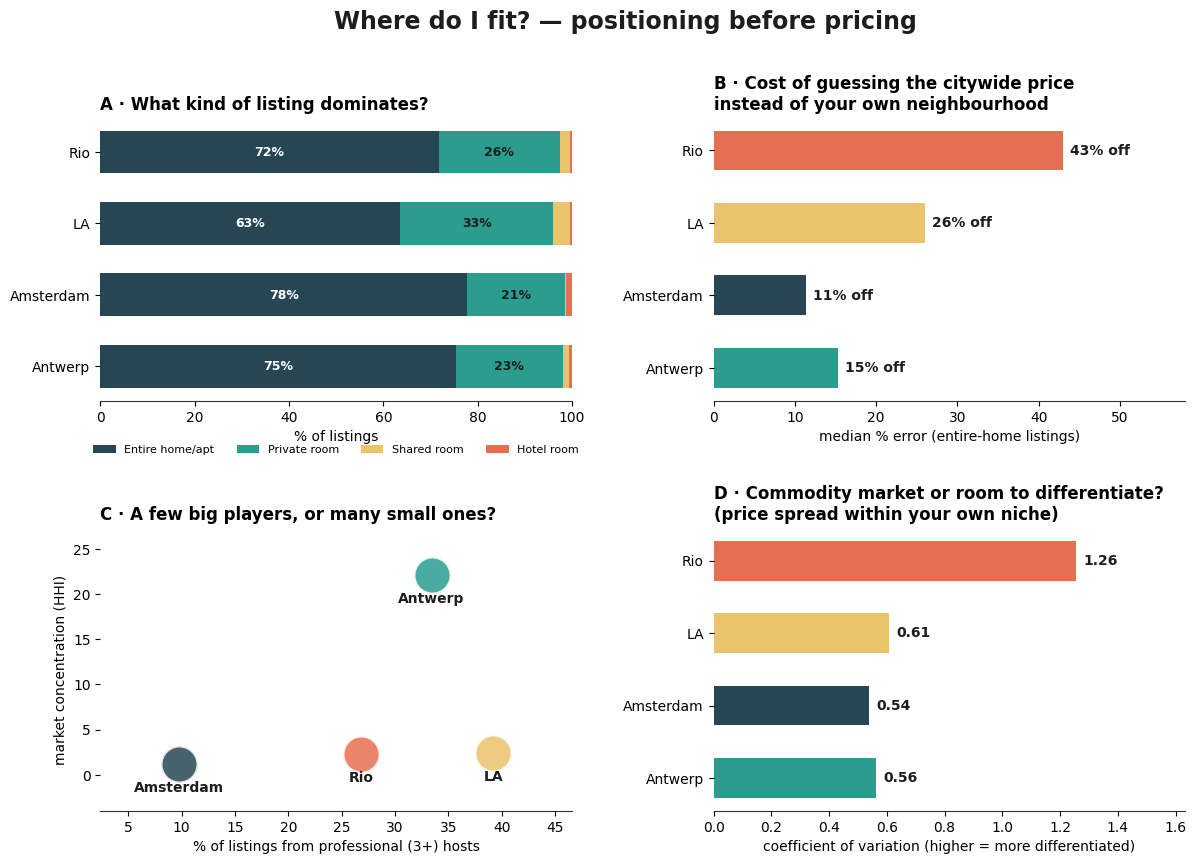

In [2]:
fig = plt.figure(figsize=(14, 9))
gs = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.3)
fig.suptitle('Where do I fit? — positioning before pricing', fontsize=17, fontweight='bold', color=INK, y=1.00)

# Panel A: room type mix
ax = fig.add_subplot(gs[0, 0])
mix = pd.crosstab(data['city'], data['room_type'], normalize='index').reindex(ORDER)[
    ['Entire home/apt', 'Private room', 'Shared room', 'Hotel room']] * 100
left = np.zeros(len(ORDER))
seg_colors = ['#264653', '#2a9d8f', '#e9c46a', '#e76f51']
for col, c in zip(mix.columns, seg_colors):
    bars = ax.barh(ORDER, mix[col], left=left, color=c, height=0.6, label=col)
    for y, (l, v) in enumerate(zip(left, mix[col])):
        if v > 6:
            ax.text(l + v / 2, y, f'{v:.0f}%', ha='center', va='center', fontsize=9,
                     color='white' if col in ['Entire home/apt', 'Entire home/apt'] else INK, fontweight='bold')
    left += mix[col].values
ax.set_xlim(0, 100)
ax.set_title('A · What kind of listing dominates?', fontsize=12, fontweight='bold', loc='left')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False, fontsize=8)
ax.set_xlabel('% of listings')

# Panel B: cost of guessing citywide price
ax = fig.add_subplot(gs[0, 1])
errs = []
for city in ORDER:
    g = data[(data['city'] == city) & (data['room_type'] == 'Entire home/apt')]
    city_med = g['price'].median()
    nb_meds = g.groupby('neighbourhood')['price'].median()
    err = ((nb_meds - city_med).abs() / nb_meds).median() * 100
    errs.append(err)
bars = ax.barh(ORDER, errs, color=[CITY_COLOR[c] for c in ORDER], height=0.55)
hbar_labels(ax, bars, errs, fmt='{:.0f}% off')
ax.set_xlim(0, max(errs) * 1.35)
ax.set_title('B · Cost of guessing the citywide price\ninstead of your own neighbourhood', fontsize=12, fontweight='bold', loc='left')
ax.set_xlabel('median % error (entire-home listings)')

# Panel C: concentration bubble
ax = fig.add_subplot(gs[1, 0])
for city in ORDER:
    g = data[data['city'] == city]
    pro_share = g['professional'].mean() * 100
    hc = g.groupby('host_id').size()
    hhi = ((hc / hc.sum()) ** 2).sum() * 10000
    ax.scatter(pro_share, hhi, s=700, color=CITY_COLOR[city], alpha=0.85, edgecolor='white', linewidth=2, zorder=3)
    ax.annotate(city, (pro_share, hhi), xytext=(0, -20), textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold', color=INK, zorder=4)
ax.set_xlabel('% of listings from professional (3+) hosts')
ax.set_ylabel('market concentration (HHI)')
ax.set_title('C · A few big players, or many small ones?', fontsize=12, fontweight='bold', loc='left')
ax.margins(0.25)

# Panel D: price dispersion (commodity vs differentiated)
ax = fig.add_subplot(gs[1, 1])
cvs = []
for city in ORDER:
    g = data[data['city'] == city]
    vals = []
    for (_, _), cell in g.groupby(['neighbourhood', 'room_type']):
        if len(cell) >= 8:
            q1, q3 = cell['price'].quantile([0.25, 0.75])
            med = cell['price'].median()
            if med > 0: vals.append((q3 - q1) / med)
    cvs.append(np.median(vals))
bars = ax.barh(ORDER, cvs, color=[CITY_COLOR[c] for c in ORDER], height=0.55)
hbar_labels(ax, bars, cvs, fmt='{:.2f}')
ax.set_xlim(0, max(cvs) * 1.3)
ax.set_title('D · Commodity market or room to differentiate?\n(price spread within your own niche)', fontsize=12, fontweight='bold', loc='left')
ax.set_xlabel('coefficient of variation (higher = more differentiated)')

plt.show()

**What this dashboard says, in one breath:** LA is the most room-diverse market (33% private rooms, a real shared-room niche); Rio punishes a lazy citywide-average guess the hardest (**43% off**); Antwerp is dominated by a small handful of large operators (highest concentration) while LA has many mid-sized ones; and Rio is by far the most differentiated market to price into — nearly **2x** the price spread of Amsterdam or Antwerp within the exact same niche. Rio rewards research and penalizes shortcuts more than any other city here.

---
## Master Question 2 — How do I configure the listing to actually get booked?

Once you know where you sit, four levers are yours to pull: room type, minimum stay, whether to price like the big operators, and how a track record affects what you can charge.

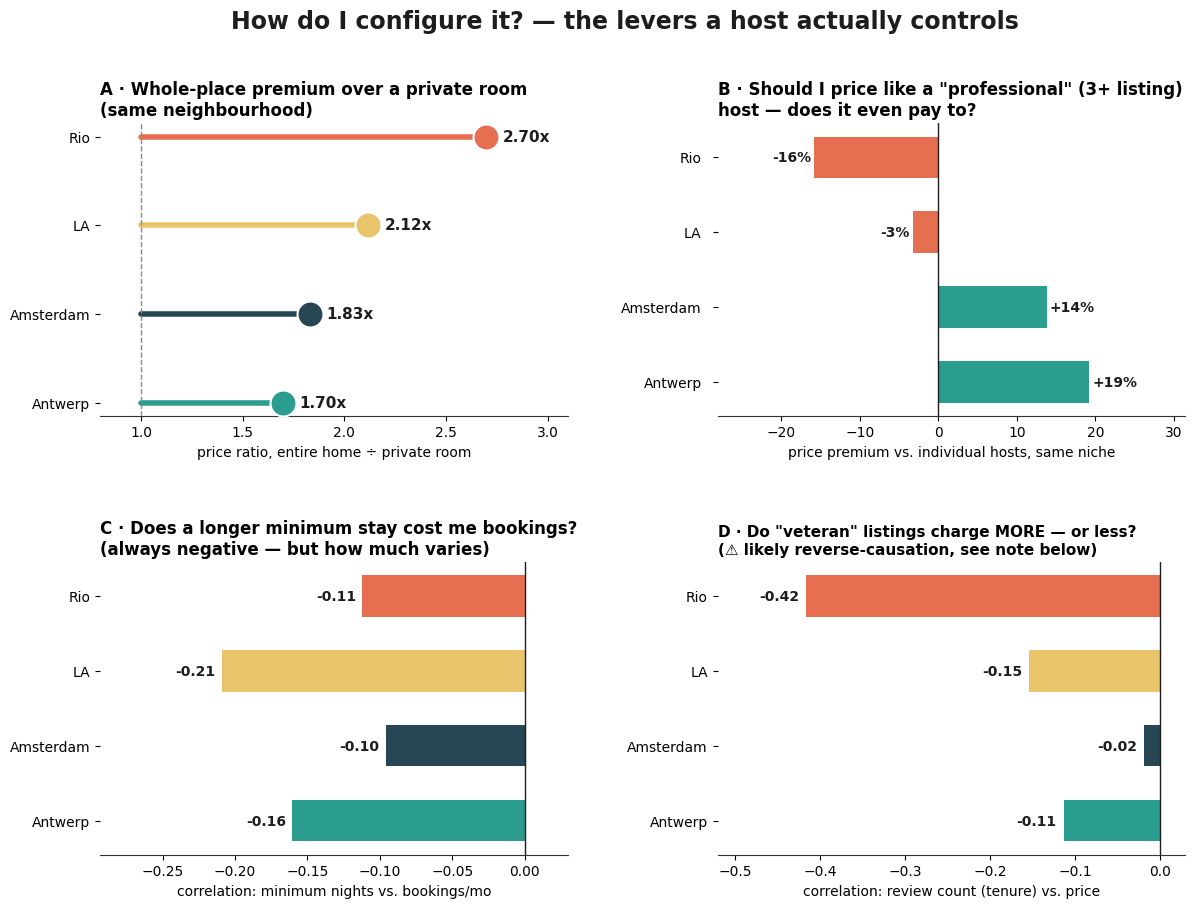

In [3]:
fig = plt.figure(figsize=(14, 9.5))
gs = GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.32)
fig.suptitle('How do I configure it? — the levers a host actually controls', fontsize=17, fontweight='bold', color=INK, y=1.00)

# Panel A: entire-home premium lollipop
ax = fig.add_subplot(gs[0, 0])
ratios = []
for city in ORDER:
    g = data[data['city'] == city]
    vals = []
    for _, cell in g.groupby('neighbourhood'):
        eh = cell.loc[cell['room_type'] == 'Entire home/apt', 'price']
        pr = cell.loc[cell['room_type'] == 'Private room', 'price']
        if len(eh) >= 3 and len(pr) >= 3:
            vals.append(eh.median() / pr.median())
    ratios.append(np.median(vals))
y = np.arange(len(ORDER))
for yi, city, r in zip(y, ORDER, ratios):
    ax.plot([1, r], [yi, yi], color=CITY_COLOR[city], lw=4, solid_capstyle='round', zorder=2)
    ax.scatter([r], [yi], s=350, color=CITY_COLOR[city], zorder=3, edgecolor='white', linewidth=1.5)
    ax.text(r + 0.08, yi, f'{r:.2f}x', va='center', fontsize=11, fontweight='bold', color=INK)
ax.axvline(1.0, color=MUTE, lw=1, ls='--')
ax.set_yticks(y); ax.set_yticklabels(ORDER)
ax.set_xlim(0.8, 3.1)
ax.set_title('A · Whole-place premium over a private room\n(same neighbourhood)', fontsize=12, fontweight='bold', loc='left')
ax.set_xlabel('price ratio, entire home ÷ private room')

# Panel B: professional pricing premium (diverging)
ax = fig.add_subplot(gs[0, 1])
prems = []
for city in ORDER:
    g = data[data['city'] == city]
    vals = []
    for (_, _), cell in g.groupby(['neighbourhood', 'room_type']):
        pro = cell.loc[cell['professional'], 'price']; ind = cell.loc[~cell['professional'], 'price']
        if len(pro) >= 3 and len(ind) >= 3:
            vals.append((pro.median() - ind.median()) / ind.median())
    prems.append(np.median(vals) * 100)
colors = ['#2a9d8f' if v > 0 else '#e76f51' for v in prems]
bars = ax.barh(ORDER, prems, color=colors, height=0.55)
hbar_labels(ax, bars, prems, fmt='{:+.0f}%')
ax.axvline(0, color=INK, lw=1)
lo, hi = min(prems), max(prems)
pad = (hi - lo) * 0.35
ax.set_xlim(lo - pad, hi + pad)
ax.tick_params(axis='y', pad=8)
ax.set_title('B · Should I price like a "professional" (3+ listing)\nhost — does it even pay to?', fontsize=12, fontweight='bold', loc='left')
ax.set_xlabel('price premium vs. individual hosts, same niche')

# Panel C: minimum-stay elasticity
ax = fig.add_subplot(gs[1, 0])
rhos = []
for city in ORDER:
    g = data[data['city'] == city]
    vals = []
    for (_, _), cell in g.groupby(['neighbourhood', 'room_type']):
        if len(cell) >= 10 and cell['minimum_nights'].nunique() > 1:
            r, _ = stats.spearmanr(cell['minimum_nights'], cell['reviews_per_month'])
            if not np.isnan(r): vals.append(r)
    rhos.append(np.median(vals))
bars = ax.barh(ORDER, rhos, color=[CITY_COLOR[c] for c in ORDER], height=0.55)
hbar_labels(ax, bars, rhos, fmt='{:.2f}')
ax.axvline(0, color=INK, lw=1)
ax.set_xlim(min(rhos) * 1.4, 0.03)
ax.set_title('C · Does a longer minimum stay cost me bookings?\n(always negative — but how much varies)', fontsize=12, fontweight='bold', loc='left')
ax.set_xlabel('correlation: minimum nights vs. bookings/mo')

# Panel D: tenure vs price (counter-intuitive)
ax = fig.add_subplot(gs[1, 1])
rhos2 = []
for city in ORDER:
    g = data[data['city'] == city]
    vals = []
    for (_, _), cell in g.groupby(['neighbourhood', 'room_type']):
        if len(cell) >= 10 and cell['number_of_reviews'].nunique() > 1:
            r, _ = stats.spearmanr(cell['number_of_reviews'], cell['price'])
            if not np.isnan(r): vals.append(r)
    rhos2.append(np.median(vals))
bars = ax.barh(ORDER, rhos2, color=[CITY_COLOR[c] for c in ORDER], height=0.55)
hbar_labels(ax, bars, rhos2, fmt='{:.2f}')
ax.axvline(0, color=INK, lw=1)
ax.set_xlim(min(rhos2) * 1.25, 0.03)
ax.set_title('D · Do "veteran" listings charge MORE — or less?\n(⚠ likely reverse-causation, see note below)', fontsize=11, fontweight='bold', loc='left')
ax.set_xlabel('correlation: review count (tenure) vs. price')

plt.show()

**What this dashboard says:** entire-place always beats private-room (1.7x–2.7x) and longer minimum stays always cost bookings — those two rules hold everywhere, only the size changes. But panel B is the one to remember: pricing like a big operator **pays off in Antwerp (+19%) and Amsterdam (+14%)**, is a wash in LA, and is a mistake in Rio (**-16%**) — the same strategic instinct gives opposite results depending on the city. Panel D is the most counter-intuitive finding in the whole dataset — listings with more accumulated reviews charge *less*, steepest in Rio. **This is almost certainly not "experience earns a discount."** A cheap listing books faster and racks up reviews faster over the same calendar time than an expensive one does — the arrow of causation runs from price to review count, not the other way round. Read it as a warning about the data, not a pricing tip.

---
## Master Question 3 — Does the capital math actually work?

This is the question that turns "I could list a room I own" into "should I buy something to run this as a business." It needs outside data: 2026 property prices per m², and each city's own short-term rental law.

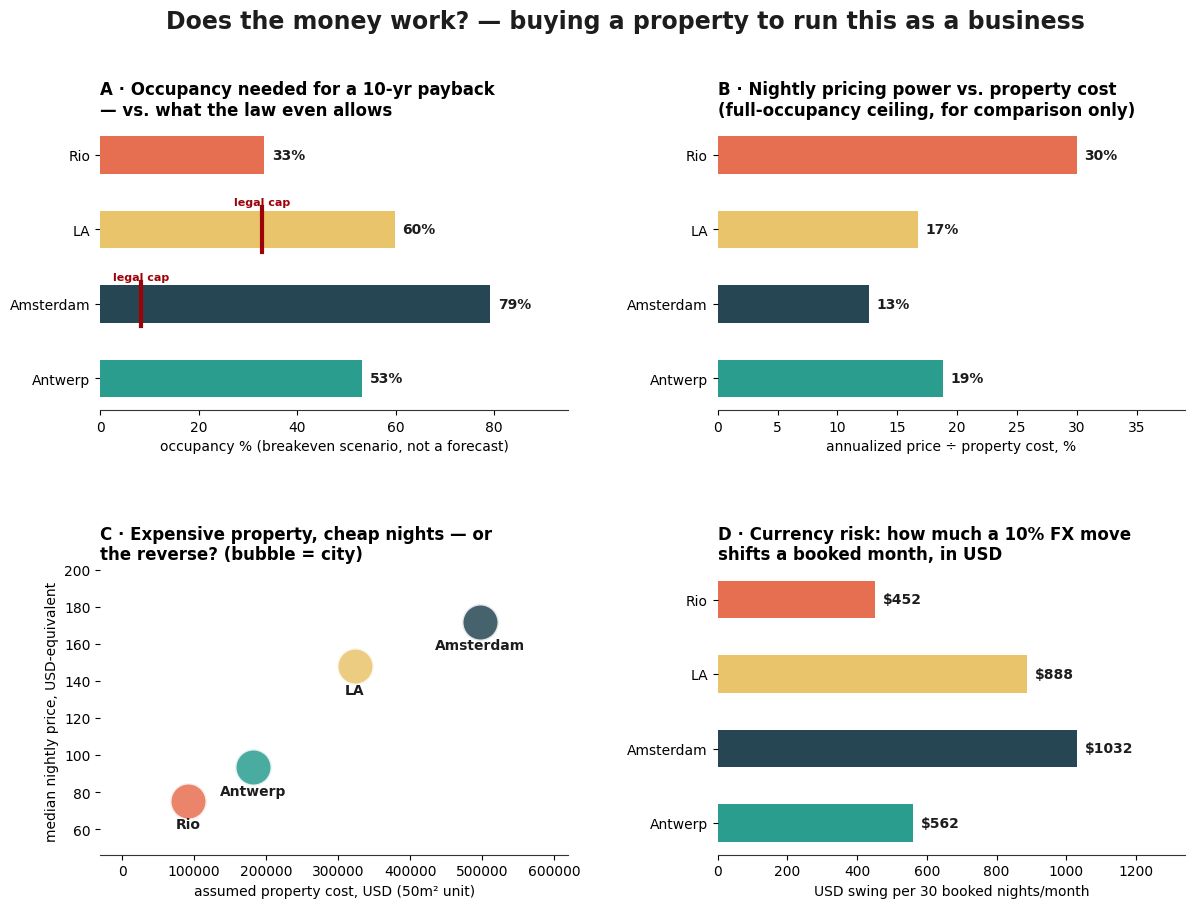

In [4]:
PPSQM = {'Antwerp': 3100, 'Amsterdam': 8500, 'LA': 6458, 'Rio': 9500}
FX_TO_USD = {'Antwerp': 1.17, 'Amsterdam': 1.17, 'LA': 1.0, 'Rio': 1 / 5.19}
UNIT_SIZE = 50
LEGAL_CAP_PCT = {'Antwerp': None, 'Amsterdam': 30 / 365 * 100, 'LA': 120 / 365 * 100, 'Rio': None}

fig = plt.figure(figsize=(14, 9.5))
gs = GridSpec(2, 2, figure=fig, hspace=0.55, wspace=0.32)
fig.suptitle('Does the money work? — buying a property to run this as a business', fontsize=17, fontweight='bold', color=INK, y=1.00)

occ, ceiling, nightly_usd, cost_usd = {}, {}, {}, {}
for city in ORDER:
    g = data[(data['city'] == city) & (data['room_type'] == 'Entire home/apt')]
    med_price = g['price'].median()
    cost = PPSQM[city] * UNIT_SIZE
    occ[city] = (cost / 10 / med_price) / 365 * 100
    ceiling[city] = (med_price * 365) / cost * 100
    nightly_usd[city] = med_price * FX_TO_USD[city]
    cost_usd[city] = cost * FX_TO_USD[city]

# Panel A: breakeven occupancy vs legal cap
ax = fig.add_subplot(gs[0, 0])
bars = ax.barh(ORDER, [occ[c] for c in ORDER], color=[CITY_COLOR[c] for c in ORDER], height=0.5, zorder=3)
hbar_labels(ax, bars, [occ[c] for c in ORDER], fmt='{:.0f}%')
for i, city in enumerate(ORDER):
    cap = LEGAL_CAP_PCT[city]
    if cap is not None:
        ax.plot([cap, cap], [i - 0.3, i + 0.3], color='#9d0208', lw=3, zorder=4)
        ax.annotate('legal cap', (cap, i + 0.32), color='#9d0208', fontsize=8, ha='center', fontweight='bold')
ax.set_title('A · Occupancy needed for a 10-yr payback\n— vs. what the law even allows', fontsize=12, fontweight='bold', loc='left')
ax.set_xlabel('occupancy % (breakeven scenario, not a forecast)')
ax.set_xlim(0, 95)

# Panel B: price-to-property-cost ceiling
ax = fig.add_subplot(gs[0, 1])
bars = ax.barh(ORDER, [ceiling[c] for c in ORDER], color=[CITY_COLOR[c] for c in ORDER], height=0.5)
hbar_labels(ax, bars, [ceiling[c] for c in ORDER], fmt='{:.0f}%')
ax.set_title('B · Nightly pricing power vs. property cost\n(full-occupancy ceiling, for comparison only)', fontsize=12, fontweight='bold', loc='left')
ax.set_xlabel('annualized price ÷ property cost, %')
ax.set_xlim(0, max(ceiling.values()) * 1.3)

# Panel C: property cost vs nightly price, USD-normalized bubble
ax = fig.add_subplot(gs[1, 0])
for city in ORDER:
    ax.scatter(cost_usd[city], nightly_usd[city], s=700, color=CITY_COLOR[city], alpha=0.85, edgecolor='white', linewidth=2, zorder=3)
    ax.annotate(city, (cost_usd[city], nightly_usd[city]), xytext=(0, -20), textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold', color=INK, zorder=4)
ax.set_xlabel('assumed property cost, USD (50m² unit)')
ax.set_ylabel('median nightly price, USD-equivalent')
ax.set_title('C · Expensive property, cheap nights — or\nthe reverse? (bubble = city)', fontsize=12, fontweight='bold', loc='left')
ax.margins(0.3)

# Panel D: FX exposure
ax = fig.add_subplot(gs[1, 1])
swing = {c: nightly_usd[c] * 0.20 * 30 for c in ORDER}
bars = ax.barh(ORDER, [swing[c] for c in ORDER], color=[CITY_COLOR[c] for c in ORDER], height=0.5)
hbar_labels(ax, bars, [swing[c] for c in ORDER], fmt='${:.0f}')
ax.set_title('D · Currency risk: how much a 10% FX move\nshifts a booked month, in USD', fontsize=12, fontweight='bold', loc='left')
ax.set_xlabel('USD swing per 30 booked nights/month')
ax.set_xlim(0, max(swing.values()) * 1.3)

plt.show()

**What this dashboard says, and it's the biggest single finding in the whole analysis:** Amsterdam's breakeven scenario needs **~79% occupancy** for a 10-year payback — but Amsterdam's own law caps unhosted rentals at 30 nights a year, which is **8.2% occupancy.** Panel A shows that gap directly: the red mark (legal cap) doesn't even come close to the bar. Buying a property to run as a pure Airbnb business in Amsterdam doesn't just look financially weak — it is arithmetically blocked by the city's own regulation. Rio is the opposite extreme: cheapest breakeven (33% occupancy) and the best pricing-power-to-property-cost ratio (30%, roughly double Amsterdam's 13%) — the property is still cheap relative to what a night there can charge.

---
## Master Question 4 — What could take this away from me, and is the income even real?

The last question ties the money to two things a spreadsheet won't tell you: how the income compares to what a local actually earns, and how exposed the whole thing is to a regulator's pen.

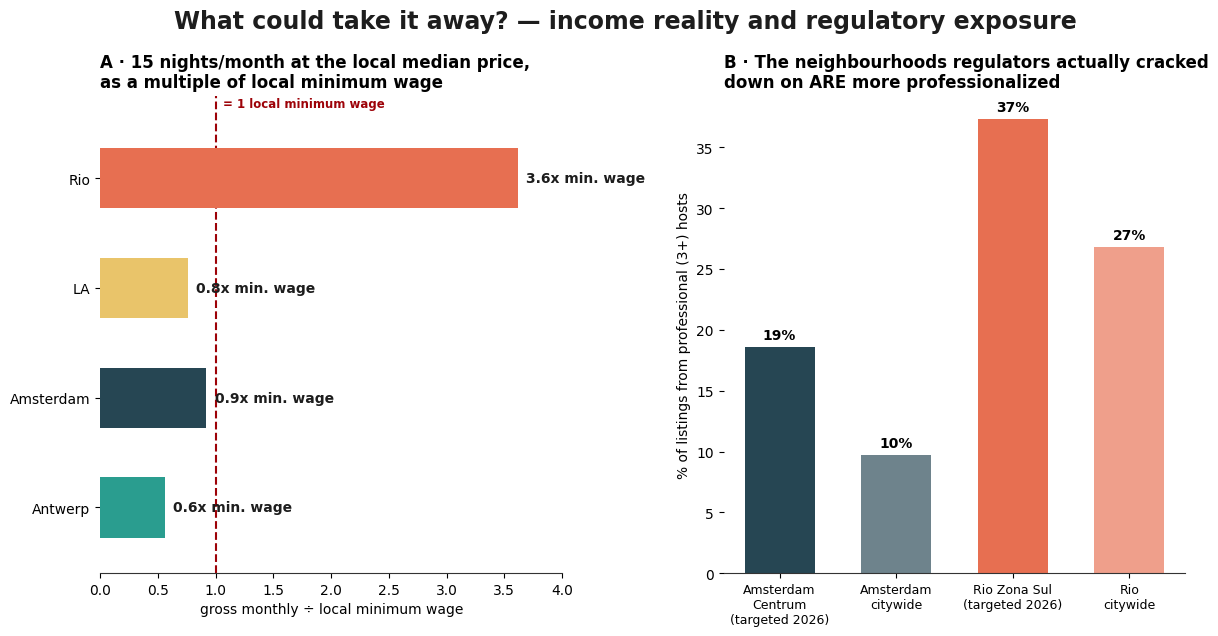

In [5]:
MINWAGE = {'Antwerp': 2154, 'Amsterdam': 2400, 'LA': 2929, 'Rio': 1621}

fig = plt.figure(figsize=(14, 6.2))
gs = GridSpec(1, 2, figure=fig, wspace=0.35)
fig.suptitle('What could take it away? — income reality and regulatory exposure', fontsize=17, fontweight='bold', color=INK, y=1.02)

# Panel A: income vs minimum wage — the headline number
ax = fig.add_subplot(gs[0, 0])
ratio = {}
for city in ORDER:
    g = data[(data['city'] == city) & (data['room_type'] == 'Entire home/apt')]
    med_price = g['price'].median()
    ratio[city] = (med_price * 15) / MINWAGE[city]
bars = ax.barh(ORDER, [ratio[c] for c in ORDER], color=[CITY_COLOR[c] for c in ORDER], height=0.55, zorder=3)
hbar_labels(ax, bars, [ratio[c] for c in ORDER], fmt='{:.1f}x min. wage')
ax.axvline(1.0, color='#9d0208', lw=1.5, ls='--', zorder=2)
ax.text(1.06, 3.62, '= 1 local minimum wage', color='#9d0208', fontsize=8.5, fontweight='bold', ha='left', va='bottom')
ax.set_ylim(-0.6, 3.75)
ax.set_title('A · 15 nights/month at the local median price,\nas a multiple of local minimum wage', fontsize=12, fontweight='bold', loc='left')
ax.set_xlabel('gross monthly ÷ local minimum wage')
ax.set_xlim(0, 4)

# Panel B: professionalization in the neighbourhoods regulators actually targeted
ax = fig.add_subplot(gs[0, 1])
ams_c = data[(data['city'] == 'Amsterdam') & (data['neighbourhood'].str.contains('Centrum', case=False, na=False))]
ams_a = data[data['city'] == 'Amsterdam']
rio_zs = data[(data['city'] == 'Rio') & (data['neighbourhood'].isin(['Copacabana', 'Ipanema', 'Leblon']))]
rio_a = data[data['city'] == 'Rio']
labels = ['Amsterdam\nCentrum\n(targeted 2026)', 'Amsterdam\ncitywide', 'Rio Zona Sul\n(targeted 2026)', 'Rio\ncitywide']
vals = [ams_c['professional'].mean() * 100, ams_a['professional'].mean() * 100,
        rio_zs['professional'].mean() * 100, rio_a['professional'].mean() * 100]
cols = ['#264653', '#264653aa', '#e76f51', '#e76f51aa']
bars = ax.bar(labels, vals, color=cols, width=0.6)
hbar_labels_v = None
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.6, f'{v:.0f}%', ha='center', fontweight='bold', fontsize=10)
ax.set_title('B · The neighbourhoods regulators actually cracked\ndown on ARE more professionalized', fontsize=12, fontweight='bold', loc='left')
ax.set_ylabel('% of listings from professional (3+) hosts')
plt.setp(ax.get_xticklabels(), fontsize=9)

plt.show()

**What this dashboard says, and it's the sharpest number in the whole analysis:** in Rio, a modest 15-night month at the local median price comes to **3.6x local minimum wage** — this isn't supplemental income, it's an investment-grade return that dwarfs local earning power. In Antwerp, the same 15-night month is **0.56x** minimum wage — genuinely just extra cash, not a living. That gap is exactly why Rio faces investor-driven-conversion backlash (condo votes, proposed bans) and Antwerp doesn't: panel B shows the *specific* neighbourhoods regulators targeted in 2026 (Amsterdam Centrum, Rio's Zona Sul) both run meaningfully more professionalized than their own citywide average. The places making the most Airbnb money relative to local wages are the same places regulators are moving against first.

---
## The four questions, side by side

One scorecard, four cities, the headline number from each master question.

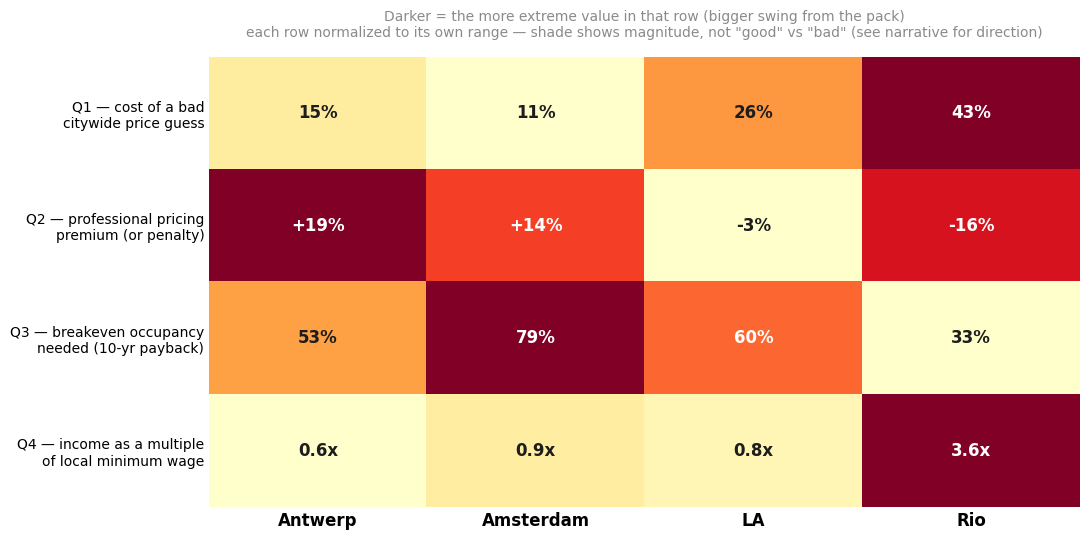

In [6]:
fig, ax = plt.subplots(figsize=(11, 5.5))
rows = ['Q1 — cost of a bad\ncitywide price guess', 'Q2 — professional pricing\npremium (or penalty)',
        'Q3 — breakeven occupancy\nneeded (10-yr payback)', 'Q4 — income as a multiple\nof local minimum wage']
raw = {
    'Q1 — cost of a bad\ncitywide price guess': {c: errs[i] for i, c in enumerate(ORDER)},
    'Q2 — professional pricing\npremium (or penalty)': {c: prems[i] for i, c in enumerate(ORDER)},
    'Q3 — breakeven occupancy\nneeded (10-yr payback)': occ,
    'Q4 — income as a multiple\nof local minimum wage': ratio,
}
mat = np.array([[raw[r][c] for c in ORDER] for r in rows])
mag = np.abs(mat - np.where(np.arange(len(rows))[:, None] == 1, 0, mat.min(axis=1, keepdims=True)))
norm = (mag - mag.min(axis=1, keepdims=True)) / (mag.max(axis=1, keepdims=True) - mag.min(axis=1, keepdims=True) + 1e-9)

im = ax.imshow(norm, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(ORDER))); ax.set_xticklabels(ORDER, fontsize=12, fontweight='bold')
ax.set_yticks(range(len(rows))); ax.set_yticklabels(rows, fontsize=10)
for i in range(len(rows)):
    for j in range(len(ORDER)):
        fmt = '{:.0f}%' if i != 1 else '{:+.0f}%'
        txt = fmt.format(mat[i, j]) if i in (0, 1, 2) else f'{mat[i, j]:.1f}x'
        ax.text(j, i, txt, ha='center', va='center', fontsize=12, fontweight='bold',
                 color='white' if norm[i, j] > 0.55 else '#1d1d1d')
ax.set_title('Darker = the more extreme value in that row (bigger swing from the pack)\neach row normalized to its own range — shade shows magnitude, not "good" vs "bad" (see narrative for direction)',
              fontsize=10, color=MUTE, pad=14)
for spine in ax.spines.values(): spine.set_visible(False)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

No single city wins on all four. **Rio** is the highest-reward, highest-scrutiny market — best income multiple, but a professional-pricing penalty and the most differentiated (hardest-to-guess) pricing landscape. **Antwerp** is the calmest — modest income, but a professional-pricing edge and the lowest capital risk. **Amsterdam** is capital-unfriendly by regulation itself (Q3), even though its day-to-day economics look reasonable. **LA** sits in the middle on every measure — the least extreme city on this board, in either direction.